In [1]:
## Libraries laden

library(tidyverse)
library(sf)
library(hms)
library(forcats)
library(tmap)
library(patchwork)
library(adehabitatHR)
library(scales)
library(knitr)
library(IRdisplay)

── Attaching core tidyverse packages ──────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.2
✔ ggplot2   4.0.0     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.1.0     
── Conflicts ────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Linking to GEOS 3.13.1, GDAL 3.11.0, PROJ 9.6.0; sf_use_s2() is TRUE


Attache Paket: 'hms'


Das folgende Objekt ist maskiert 'package:lubridate':

    hms


Lade nötiges Paket: sp

Lade nötiges Paket: ade4

Lade nötiges Paket: adehabitatMA

Registered S3 methods overwritten by 'adehabitatMA':
  method                       from
  print.SpatialPixelsDataFrame sp  
  print.SpatialPixels       

# Abstract

In dieser Arbeit werden GPS-Daten von 92 Katzen aus dem Raum Ás (Norwegen) im Rahmen der Computational Movement Analysis (CMA) untersucht. Analysiert werden tageszeitliche Aktivitätsmuster, Home Ranges sowie raumzeitliche Begegnungen. Die Resultate zeigen erhöhte Aktivität in der Abenddämmerung und in der Nacht, deutliche Unterschiede in der Home Range-Grösse (insbesondere urbane vs. ländliche Katzen-Typen) sowie mehr Begegnungen in überlappenden Home Ranges, deren Häufigkeit jedoch bei mehr als drei Überlappungen wieder abnimmt. Insgesamt verdeutlichen die Ergebnisse sowohl Möglichkeiten als auch Grenzen GPS-basierter Bewegungsanalysen.

# Einleitung

Katzen sind Raubtiere, deren Bewegungsverhalten entscheidend für das Verständnis ihrer Raumnutzung und ökologischen Auswirkungen ist, was sie besonders geeignet für Bewegungsanalysen macht (Bischof et al., 2022). Bewegungsdaten wie GPS-Daten liefern dabei raumzeitliche Informationen, die sowohl Positionen als auch deren Veränderung über die Zeit beschreiben und typisch sind in der Computational Movement Analysis (CMA) (Laube, 2014; Dodge et al., 2013).  In diesem Projekt werden GPS-Daten von 92 Katzen im Raum Ás (nahe Oslo) analysiert. Ziel ist die Untersuchung ihres Bewegungsverhaltens anhand verschiedener Methoden der Bewegungsanalyse. Im Zentrum stehen drei Forschungsfragen (RQ):

* RQ1: Zu welcher Tageszeit sind Katzen am aktivsten?
* RQ2: Wie gross sind die Streifgebiete der Katzen und wie stark unterscheiden sie sich zwischen Individuen? 
* RQ3: Wie häufig begegnen sich Katzen bei einer bestimmten Katzendichte?

Katzen gelten als überwiegend dämmerungs- und nachtaktive Tiere, deren Aktivität stark von Lichtbedingungen beeinflusst wird (Merčnik et al., 2023). Sie werden oft als territorial eingeschätzt - die Literatur zeigt jedoch, dass territoriales Verhalten kontextabhängig ist und nicht bei allen Katzen gleich ausgeprägt auftritt (Crowell-Davis et al., 2004). 

Das Konzept der Home Range beschreibt den regelmässig genutzten Lebensraum eines Tieres zur Nutzung essenzieller Ressourcen (Powell und Mitchell, 2012). GPS-basierte Methoden erlauben präzise Schätzungen, etwa mittels der Kernel Density-Methode (Worton, 1989), welche in dieser Arbeit verwendet wird.

# Material und Methoden

## Daten

Für die Analyse wurde der öffentlich auf GitHub verfügbare Datensatz **[CatTrack_public](https://github.com/richbi/CatTrack_public)** verwendet, der GPS-Daten von 92 Katzen im Raum Oslo (Ás) enthält. Die Daten umfassen Zeitdaten sowie räumliche Positionen der Katzen während des Monats Mai 2021 und sind mit einem unbekannten räumlichen Versatz ausgestattet, um die Anonymität der Katzenbesitzer*innen zu wahren. 

Die GPS-Katzendaten entsprechen der Lagrange-Perspektive, welche es ermöglicht, Individuen kontinuierlich zu verfolgen. Sie erlaubt die Analyse individueller Bewegungsmuster wie Distanz, Geschwindigkeit und Aufenthaltsgebiete (Laube, 2017). .

Für die Unterteilung der Tageszeiten wurden zusätzlich [tages- und ortspezifische  Informationen](https://www.timeanddate.com/sun/norway/oslo?month=5&year=2021) zu Sonnenauf- und untergang sowie den Morgen- und Abenddämmerungszeiten integriert. Um die Home Ranges nach Katzentyp (urban/ländlich) unterscheiden zu können, wurden Daten aus [OpenStreetMap](https://download.geofabrik.de/europe/norway.html?utm) zur Identifikation der Landschaftstypen hinzugezogen. 

In [2]:
###############################
# Katzendaten einlesen
###############################

## Gemäss Datenquelle sei es EPSG 25833, aber die Koordinaten sind in WGS84.
## Loop zum einlesen aller Katzendaten
cats_list <- list()

for (i in 1:92) {
  file_path <- paste0("cat_GPS_data/cat_", i, ".csv")
  
  cats_list[[as.character(i)]] <- read_delim(file_path, delim = ",") %>%
    mutate(cat_id = i)
}

## Zusammensetzen zu einem Dataset
cats_all <- bind_rows(cats_list)

## überprüfen
# head(cats_all)

## In sf-Objekt umwandeln:
## Die Koordinaten zeigen klar, dass es sich um geographische Koordinaten 
## handeln muss (WGS84). Die Daten werden entsprechend mit WGS84 eingelesen 
## und in EPSG 25833 transformiert für die weiteren Analysen.
cats_all <- cats_all %>% 
    st_as_sf(coords = c("x", "y"), crs = 4326) %>%
    st_transform(crs = 25833)

## überprüfen
# head(cats_all)
# min(cats_all$datetime)
# max(cats_all$datetime)

###############################
# Daten zu Sonnenauf- und untergang einlesen
###############################

times <- read_delim("oslo_sun_times_may2021.csv", ";")
# head(times)

## Layers betrachten
layers <- st_layers("ostlandet.gpkg")
# print(layers)

## Daten einlesen
osm_landuse <- st_read(
  "ostlandet.gpkg",
  layer = "gis_osm_landuse_a_free",
  quiet = TRUE)

Rows: 6412 Columns: 3
── Column specification ────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: ","
dbl  (2): x, y
dttm (1): datetime

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 4480 Columns: 3
── Column specification ────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: ","
dbl  (2): x, y
dttm (1): datetime

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 4319 Columns: 3
── Column specification ────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: ","
dbl  (2): x, y
dttm (1): datetime

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_c

## Methoden

Die Analyse beleuchtet unterschiedliche Aspekte des Bewegungsverhaltens der 92 Katzen. Die Datenanalyse wurde in R (Version 4.5.1) durchgeführt. 

### Aktivitätsmuster

Für die Analyse wurden **Geschwindigkeit** und **zurückgelegte Distanz** als Proxies für Aktivität definiert. Beide sind zentrale Bewegungsparameter der CMA (Dodge et al., 2008). Die GPS-Daten wurden mit Sonnenauf- und untergang sowie Dämmerungsphasen verknüpft und jedem GPS-Punkt eine Tageszeitkategorie, basierend auf biologischen Lichtverhältnissen, zugewiesen:

In [3]:
###############################
# Tabellen joinen
###############################

## Zeit aus datetime extrahieren 
cats_all <- cats_all %>%
    mutate(day = day(datetime), time = as_hms(datetime))
# head(cats_all)

## Tabellen joinen über "day"
cats_all_joined <- left_join(cats_all, times, by = "day")
# head(cats_all_joined)

###############################
# Tageszeit zuweisen
###############################

cats_all_joined <- cats_all_joined %>%
  mutate(daytime = case_when(
      time >= sunrise & time <= sunset ~ "day",
      time >= civil_dawn & time < sunrise ~ "dawn",
      time > sunset & time <= civil_dusk ~ "dusk",
      time < civil_dawn | time > civil_dusk ~ "night")
  )
# head(cats_all_joined)

## Tabelle vereinfachen
cats_all_joined <- cats_all_joined %>%
    select(-c("sunrise", "sunset", "civil_dawn", "civil_dusk"))
# head(cats_all_joined)

## überprüfen
# unique(cats_all_joined$daytime)

## Speicherplatz freigeben
# remove(cats_all)
# remove(times)

###############################
# Tabelle Tageszeiten ausgeben
###############################

sun_table_description <- tibble(
  variable = c("Morgendämmerung", "Tag", "Abenddämmerung", "Nacht"),
  description = c(
    "Bürgerliche Morgendämmerung bis Sonnenaufgang",
    "Sonnenaufgang bis Sonnuntergang",
    "Sonnenuntergang bis bürgerliche Abenddämmerung",
    "Nachtstunden"), 
  example = c(
    "04:22 - 05:14",
    "05:15 - 21:13",
    "21:13 - 22:07",
    "22:08 - 04:17")
)

html_table <- knitr::kable(
  sun_table_description,
  format = "html",
  col.names = c("Tageszeit", "Beschreibung", "Beispiel vom 1. Mai")
)

IRdisplay::display_html(as.character(html_table))

Tageszeit,Beschreibung,Beispiel vom 1. Mai
Morgendämmerung,Bürgerliche Morgendämmerung bis Sonnenaufgang,04:22 - 05:14
Tag,Sonnenaufgang bis Sonnuntergang,05:15 - 21:13
Abenddämmerung,Sonnenuntergang bis bürgerliche Abenddämmerung,21:13 - 22:07
Nacht,Nachtstunden,22:08 - 04:17


Anhand der GPS-Daten wurde die Zeitverzögerung zwischen aufeinanderfolgenden Positionen berechnet. Zur Qualitätssicherung wurden nur Segmente mit einer maximalen Zeitverzögerung von 5 Minuten berücksichtigt. Dieser Schwellenwert ist notwendig, da Bewegungsanalysen wie Geschwindigkeit und Distanz in der CMA stark von der zeitlichen Auflösung abhängen (Laube und Purves, 2011).

Dieses Problem wird durch Laube und Purves (2011) als *«Granularity Grief»* beschrieben: Grosse Zeitabstände zwischen GPS-Punkten führen zu verzerrten Schätzungen von Geschwindigkeit und Distanz, da der tatsächliche Bewegungsweg zwischen Messpunkten unbekannt ist. Die Qualitätsanalyse zeigte, dass alle Katzen längere Zeitverzögerungen aufweisen. Selbst bei der am stärksten betroffenen Katze bleiben 86% der Segmente gültig, weshalb vorerst keine Individuen ausgeschlossen wurden. Für die validen Segmente wurden anschliessend Distanz und Geschwindigkeit zwischen aufeinanderfolgenden Punkten berechnet.

Die Distanz wurde pro Stunde standardisiert, um Unterschiede in der Länge der Tageszeitkategorien auszugleichen. Die Auswertung erfolgt deskriptiv anhand von Kennwerten und Boxplots auf Segment- und Individualebene, wobei nur Katzen mit vorhandenen Daten in allen Tageszeitkategorien berücksichtigt wurden.

In [4]:
###############################
# Timelag berechnen
###############################

## Funktion definieren
difftime_secs <- function(later, now){
    as.numeric(difftime(later, now, units = "secs"))
}

## Funktion anwenden
cats_all_joined <- cats_all_joined %>%
    group_by(cat_id) %>%
    arrange(datetime, .by_group = TRUE) %>%
    mutate(timelag = difftime_secs(lead(datetime), datetime)) %>%
    ungroup()

# head(cats_all_joined)
# cats_all_joined %>% count(cat_id)

## Hat die Gruppierung geklappt? --> NA bei Wechsel der cat_id prüfen
# cats_all_joined[6410:6415,]

## Gruppierung überprüfen --> sollte nicht mehr gruppiert sein!
# groups(cats_all_joined)

## nun sollten wir gleich viele NA haben wie Katzen --> 92!
# sum(is.na(cats_all_joined$timelag))
# sum(is.na(cats_all_joined$timelag)) == length(unique(cats_all_joined$cat_id))

###############################
# Sampling-Intervall prüfen
###############################

# paste("Im Durchschnitt", round(mean(cats_all_joined$timelag, na.rm = TRUE)/60, 0), "Minuten")
# paste("Im Median", round(median(cats_all_joined$timelag, na.rm = TRUE)/60, 0), "Minuten")

###############################
# Summary fehlende Werte / grosse Zeitabstände
###############################

## Der Mittelwert von 8 Minuten weist eine grosse Abweichung zum Median von 2 Minuten auf. 
## Aus diesem Grund wird hier ein Summary der fehlenden Werte und grosser Zeitabstände 
## erstellt, um einen Überblick über die Daten zu erlangen.

# summary(cats_all_joined$timelag)

## Das summary zeigt, dass die meisten Werte innerhalb eines Bereichs von 120 - 128 
## liegen (Min bis 3. Quartil).

## Über alle Katzen betrachtet
cats_stats <- cats_all_joined %>%
  summarise(
    n = n(),
    min = min(timelag, na.rm = TRUE),
    q25 = quantile(timelag, 0.25, na.rm = TRUE),
    median = median(timelag, na.rm = TRUE),
    q75 = quantile(timelag, 0.75, na.rm = TRUE),
    q90 = quantile(timelag, 0.90, na.rm = TRUE),
    q95 = quantile(timelag, 0.95, na.rm = TRUE),
    q99 = quantile(timelag, 0.99, na.rm = TRUE),
    max = max(timelag, na.rm = TRUE)
  )
# cats_stats

## Für jede Katze einzeln
overview_cats <- cats_all_joined %>%
    group_by(cat_id) %>%
    summarise(
        n = n(),
        n_NA = sum(is.na(timelag)),
        min = min(timelag, na.rm = TRUE),
        q25 = quantile(timelag, 0.25, na.rm = TRUE),
        median = median(timelag, na.rm = TRUE),
        mean = mean(timelag, na.rm = TRUE),
        q75 = quantile(timelag, 0.75, na.rm = TRUE),
        max = max(timelag, na.rm = TRUE)
    ) %>%
    ungroup()
# overview_cats

## Wie hoch ist der grösste timelag bei der Katze mit dem global geringsten Maximalwert?
# min(overview_cats$max)
# paste((min(overview_cats$max)/3600), "Stunden")
# boxplot(cats_all_joined$timelag)

## globales Minimum und Maximum des timelag
# min(cats_all_joined$timelag, na.rm = TRUE)
# max(cats_all_joined$timelag, na.rm = TRUE)

###############################
# Entfernung unzureichender Datensätze
###############################

## Wir schauen mal, wie viele Segmente einen timelag von > 5 Minuten aufweisen
max_lag_allowed <- 5 * 60
cats_all_joined_timelag <- cats_all_joined %>%
    mutate(valid_segment = !is.na(timelag) & timelag <= max_lag_allowed)
# head(cats_all_joined_timelag)

## valide Segmente je Katze
cat_timelag_quality <- cats_all_joined_timelag %>%
    st_drop_geometry() %>%
    group_by(cat_id) %>%
    summarise(
        n_total = n(),
        n_valid_segments = sum(valid_segment, na.rm = TRUE),
        share_valid_segments = mean(valid_segment, na.rm = TRUE),
        n_invalid_segments = sum(!valid_segment, na.rm = TRUE)
    ) %>%
    arrange(share_valid_segments)
# cat_timelag_quality

# min(cat_timelag_quality$share_valid_segments)
# median(cat_timelag_quality$share_valid_segments)
# mean(cat_timelag_quality$share_valid_segments)

###############################
# Segmente auf NA setzen
###############################

## In diesem Schritt wird die Spalte `timelag` aller invaliden Segmente auf `NA` gesetzt.

# head(cats_all_joined_timelag)

cats_all_joined_timelag_segm <- cats_all_joined_timelag %>%
    mutate(timelag = if_else(valid_segment == TRUE, timelag, NA))
# head(cats_all_joined_timelag_segm)

###############################
# Distanz berechnen
###############################

## Funktion definieren
distance_by_element <- function(later, now){
  as.numeric(
    st_distance(later, now, by_element = TRUE)
  )
}

later <- lead(cats_all_joined_timelag_segm$geometry)
now <- cats_all_joined_timelag_segm$geometry

## Variable umbenennen, alte entfernen
cats_all_joined_dist <- cats_all_joined_timelag_segm
remove(cats_all_joined_timelag_segm)

## Funktion anwenden
cats_all_joined_dist$steplength <- distance_by_element(later, now)
# head(cats_all_joined_dist)

## Segmente auf NA setzen
cats_all_joined_dist_segm <- cats_all_joined_dist %>% 
    mutate(steplength = if_else(valid_segment == TRUE, steplength, NA))

remove(cats_all_joined_dist)
# head(cats_all_joined_dist_segm)
# min(cats_all_joined_dist_segm$steplength, na.rm = TRUE)
# max(cats_all_joined_dist_segm$steplength, na.rm = TRUE)

###############################
# Geschwindigkeit berechnen
###############################

cats_all_joined_speed <- cats_all_joined_dist_segm %>%
    mutate(speed = steplength/timelag)

remove(cats_all_joined_dist_segm)
# head(cats_all_joined_speed)
# min(cats_all_joined_speed$speed, na.rm = TRUE)
# max(cats_all_joined_speed$speed, na.rm = TRUE)

###############################
# Distanz & Geschwindigkeit nach Tageszeit
###############################

# head(cats_all_joined_speed)

## daytime als Faktor
cats_rq1 <- cats_all_joined_speed %>%
  mutate(daytime = factor(daytime, levels = c("dawn", "day", "dusk", "night")))

## Valide Segmente filtern
cats_rq1_segments <- cats_rq1 %>%
  filter(valid_segment == TRUE)

## Kontrolle Ruhezeiten: Wurden GPS-Daten auch während Ruhezeiten aufgezeichnet,
## oder können die grossen Unterbrüche dadurch erklärt werden?
resting <- cats_all_joined_speed %>% 
    filter(speed == 0) %>%
    nrow()
# resting

all <- cats_all_joined_speed %>% 
    nrow()
# all

## Anteil der Punkte mit speed = 0 an Gesamtzahl der validen GPS-Punkte
# resting/all

## Interpretation: 24.3% aller validen Segmente haben einen speed == 0 
## --> dies weist darauf hin, dass das GPS-Tracking auch während Ruhezeiten aktiv war.

## Geschwindigkeit nach Tageszeit zusammenfassen (pro Katze)
rq1_speed_summary_per_cat <- cats_rq1_segments %>%
  st_drop_geometry() %>%
  group_by(cat_id, daytime) %>%
  summarise(
    n_segments = n(),
    mean_speed_m_s = mean(speed, na.rm = TRUE),
    median_speed_m_s = median(speed, na.rm = TRUE),
    q25_speed_m_s = quantile(speed, 0.25, na.rm = TRUE),
    q75_speed_m_s = quantile(speed, 0.75, na.rm = TRUE),
    .groups = "drop"
  )
# rq1_speed_summary_per_cat

###############################
# Filterung der Katzen
###############################

## Da untersucht wird, zu welcher Tageszeit Katzen am aktivsten sind 
## (speed & distance) werden für die Analyse nur Katzen beibehalten, 
## welche während allen 4 Tageszeiten gültige Segmente aufweisen.

## wie viele Katzen haben nicht 4 Tageszeiten?
not4 <- rq1_speed_summary_per_cat %>%
    count(cat_id) %>%
    filter(n < 4) %>%
    nrow()
# not4

## Katzen mit <4 Tageszeiten in Variable speichern
cats_less_4_daytimes <- rq1_speed_summary_per_cat %>%
  count(cat_id) %>%
  filter(n < 4) %>%
  pull(cat_id)
# cats_less_4_daytimes

## Katzen mit <4 Tageszeiten ausschliessen
cats_rq1_segments_filtered <- cats_rq1_segments %>%
    filter(!cat_id %in% cats_less_4_daytimes)

## überprüfen
# length(unique(cats_rq1_segments_filtered$cat_id))

### Home Ranges

Um die Grösse der Streifgebiete zu bestimmen wurden **Home Ranges** mittels Kernel Density Estimation (KDE) berechnet. Die KDE schätzt die räumliche Aufenthaltswahrscheinlichkeit der Katzen und ermöglicht dadurch eine realistische Abgrenzung von Bereichen mit unterschiedlicher Nutzungsintensität. Da die KDE die räumliche Verteilung der GPS-Punkte nutzt, eignet sie sich auch für Datensätze mit unregelmässigen Zeitabständen zwischen den GPS-Messungen, wie die vorliegenden Katzendaten (Worton, 1989; Laube, 2014). 

Aus den GPS-Punkten wurde zunächst die Utilization Distribution bestimmt und daraus die 95%-KDE Home Range abgeleitet, welche jene Fläche umfasst, in der sich eine Katze mit 95% Wahrscheinlichkeit aufhält. Die Flächen wurden in Hektaren berechnet. Ergänzend wurde eine Sensitivitätsanalyse mit der 80%-KDE durchgeführt, die den stärker genutzten Kernbereich beschreibt. 

In [5]:
# head(cats_all_joined)

## Testlauf mit einer Katze zur Kontrolle der Funktionalität
cat_test <- cats_all_joined %>%
  filter(cat_id == "4") 
# nrow(cat_test)

###############################
# 95%-KDE berechnen
###############################

## Umwandlung in ein Spatial-Objekt
cat_test_sp <- as(cat_test["cat_id"], "Spatial") 

## Kernel-Dichte-Schätzung (UD = Utilization Distribution)
kud <- kernelUD(cat_test_sp, h = "href", grid = 200) 

## Berechnung der Home Range (95% Isopleth)
## getverticeshr() erzeugt die Polygone der Home Range, hier die 95%-Isopleth.
## 95% bedeutet: Das Polygon umfasst die kleinste Fläche,
## die 95% der geschätzten Nutzung / Utilization Distribution enthält.
homerange <- getverticeshr(kud, percent = 95) 

## Home-Range-Polygon zurück in ein sf-Objekt umwandeln, 
## damit man es z. B. mit sf-Funktionen plotten oder speichern kann.
hr <- st_as_sf(homerange) 

## kurz plotten (überprüfen)
plot_test <- ggplot(hr) + 
  geom_sf(size = 1, alpha = 0.3, color = "red", fill="red") +
  geom_sf(data = cat_test, aes(fill = "red")) +
  coord_sf(crs = st_crs(25833), datum = st_crs(25833)) +
  theme(
    axis.ticks = element_blank(),
    legend.position="none"
  )
# plot_test

###############################
# Loop über alle Katzen
###############################

## leere Liste zum Speichern der Resultate (HR) anlegen
hr_list <- list()

## Vektor mit allen cat_id anlegen zum Loopen
cat_ids <- as.character(unique(cats_all_joined$cat_id))

## Loop über cat_id
for (id in cat_ids) {
  
  cat_i <- cats_all_joined %>%
    filter(as.character(cat_id) == id) %>%
    mutate(cat_id = factor(as.character(cat_id)))  # wichtig wegen Faktor-Levels
  
  cat_sp <- as(cat_i["cat_id"], "Spatial")
  
  kud <- kernelUD(cat_sp, h = "href", grid = 200)
  
  homerange <- getverticeshr(kud, percent = 95)
  
  hr <- st_as_sf(homerange) %>%
    mutate(
      cat_id = id,
      area_m2 = as.numeric(st_area(geometry)),
      area_ha = area_m2 / 10000
    )
  
  hr_list[[id]] <- hr
}

## Listen zusammenfügen
hr_all <- bind_rows(hr_list)
# hr_all

## Plotten zum betrachten
plot_test <- ggplot() +
  geom_sf(data = hr_all, aes(fill = cat_id), alpha = 0.3, show.legend = FALSE) +
#  geom_sf(data = cats_all_joined, aes(color = cat_id), size = 0.2, show.legend = FALSE) +
  coord_sf(crs = st_crs(25833), datum = st_crs(25833)) +
  theme_minimal()
# plot_test

## Flächentabelle erstellen
hr_area_summary <- hr_all %>%
  st_drop_geometry() %>%
  select(cat_id, area_m2, area_ha) %>%
  arrange(desc(area_ha))

# head(hr_area_summary)

###############################
# Sensitivitätsanalyse mit 80% KDE Home Range
###############################

## leere Liste zum Speichern der Resultate (HR) anlegen
hr_list_80 <- list()

## Vektor mit allen cat_id anlegen zum Loopen
cat_ids <- as.character(unique(cats_all_joined$cat_id))

## Loop über cat_id
for (id in cat_ids) {
  
  cat_i <- cats_all_joined %>%
    filter(as.character(cat_id) == id) %>%
    mutate(cat_id = factor(as.character(cat_id)))  # wichtig wegen Faktor-Levels
  
  cat_sp <- as(cat_i["cat_id"], "Spatial")
  
  kud <- kernelUD(cat_sp, h = "href", grid = 200)
  
  homerange <- getverticeshr(kud, percent = 80)
  
  hr <- st_as_sf(homerange) %>%
    mutate(
      cat_id = id,
      area_m2 = as.numeric(st_area(geometry)),
      area_ha = area_m2 / 10000
    )
  
  hr_list_80[[id]] <- hr
}

## Listen zusammenfügen
hr_all_80 <- bind_rows(hr_list_80)

Zur **Unterscheidung der Home Range-Grössen zwischen urbanen und ländlichen Katzen** wurden Daten zur Landnutzung aus OpenStreetMap integriert. Nach der Transformation ins metrische Koordinatensystem `EPSG:25833` wurde der Vektordatensatz mittels Bounding Box der Home Ranges auf das Katzengebiet zugeschnitten. Die verbleibenden Landnutzungskategorien wurden anschliessend als urbane (*residential, retail, industrial, commercial*) und ländliche Gebiete (*park, forest, farmland, farmyard, scrub, grass, heath, meadow, orchard*) zusammengefasst. 

Um die Katzen als urban oder ländlich zu unterscheiden, wurde die Schnittfläche der Home Ranges (95% KDE) mit der Gebietskategorie (urban/ländlich) und anschliessend der Anteil des Gebiets innerhalb jeder Home Range berechnet. Die Einteilung der Katzen in urban oder ländlich erfolgte durch die dominierende Gebietskategorie. 

In [6]:
###############################
# Katzen unterscheiden nach urban/ländlich
###############################

## Daten betrachten
# head(osm_landuse)
# st_crs(osm_landuse)
# st_geometry_type(osm_landuse)
# names(osm_landuse)
# head(osm_landuse)

## crs transformieren
osm_landuse <- osm_landuse %>%
    st_transform(st_crs(hr_all))

## clippen auf Katzengebiet
cats_bbox <- st_as_sfc(st_bbox(hr_all))
osm_landuse_clip <- st_crop(osm_landuse, cats_bbox)
# head(osm_landuse_clip)

## Verbleibende Kategorien ausgeben
# unique(osm_landuse_clip$fclass)

## Plotten
land_test <- ggplot() +
  geom_sf(data = osm_landuse_clip, aes(fill = fclass), color = NA, alpha = 0.6) +
  geom_sf(data = hr_all, fill = NA, color = "black", linewidth = 0.4) +
  coord_sf(crs = st_crs(hr_all), datum = st_crs(hr_all)) +
  labs(
    fill = "OSM landuse",
    title = "OSM landuse and cat home ranges"
  ) +
  theme_minimal()
# land_test

## Land use klassifizieren / zusammenfassen in urban und rural
osm_landuse_clip_classified <- osm_landuse_clip %>%
  mutate(
    landuse_classified = case_when(
      fclass %in% c("residential", "retail", "industrial", "commercial") ~ "urban",
      
      fclass %in% c("park", "forest", "farmland", "farmyard", "scrub", "grass",
        "heath", "meadow", "orchard") ~ "rural"
    )) 
# head(osm_landuse_clip_classified)

## Kontrolle
# unique(osm_landuse_clip_classified$landuse_classified)
# head(hr_all)
# head(osm_landuse_clip_classified)

## sicherstellen, dass CRS gleich ist
# st_crs(hr_all) == st_crs(osm_landuse_clip_classified)

###############################
# Schnittfläche der HR berechnen
###############################

## HR mit Landuse überschneiden
hr_landuse_intersection <- st_intersection(
  hr_all, osm_landuse_clip_classified)
# head(hr_landuse_intersection)

## Schnittflächen berechnen
hr_landuse_area <- hr_landuse_intersection %>%
  mutate(intersection_area_m2 = as.numeric(st_area(.))) %>%
  st_drop_geometry() %>%
  group_by(cat_id, landuse_classified) %>%
  summarise(
    area_m2 = sum(intersection_area_m2, na.rm = TRUE),
    .groups = "drop"
  )
# head(hr_landuse_area)

###############################
# Urban/rural-Anteil pro HR berechnen
###############################

## ins wide-format bringen
hr_landuse_wide <- hr_landuse_area %>%
  pivot_wider(
    names_from = landuse_classified,
    values_from = area_m2,
    values_fill = 0)

## klassifizieren
hr_landuse_class <- hr_landuse_wide %>%
  mutate(
    classified_area_m2 = urban + rural,
    urban_share = urban / classified_area_m2,
    rural_share = rural / classified_area_m2,
    cat_environment = case_when(
      urban_share > rural_share ~ "urban",
      rural_share > urban_share ~ "rural"
    ))
# head(hr_landuse_class)

## Mit Home-Range-Fläche verbinden
hr_area_environment <- hr_area_summary %>%
  left_join(
    hr_landuse_class %>%
      select(cat_id, urban, rural, classified_area_m2, urban_share, rural_share, cat_environment),
    by = "cat_id")
# hr_area_environment %>% count(cat_environment)

Warning message:
"attribute variables are assumed to be spatially constant throughout all geometries"
Warning message:
"attribute variables are assumed to be spatially constant throughout all geometries"


### Begegnungen

Für die Analyse der Begegnungen wurde eine **Begegnung als raumzeitliche Nähe zweier Katzen** definiert. Zwei GPS-Fixes wurden als Begegnung gewertet, wenn sie höchstens 10 Meter voneinander entfernt waren und die Zeitstempel höchstens 60 Sekunden auseinanderlagen. Die Wahl dieser Schwellenwerte berücksichtigt sowohl die GPS-Ungenauigkeit als auch die zeitlichen Unterschiede zwischen den Aufzeichnungen der Punkte. Die Schwellenwerte orientieren sich an typischen GPS-Fehlergrössen sowie an Ansätzen der raumzeitlichen Interaktionsanalyse in der Bewegungsökologie (Dodge et al., 2008; Long et al., 2014).

Da ein direkter Vergleich aller GPS-Punkte mit allen anderen Punkten aufgrund der Datenmenge rechnerisch ineffizient wäre, wurde zunächst eine zeitliche Vorselektion durchgeführt. Dazu wurde jeder Zeitstempel auf die jeweilige Minute abgerundet und als neue Variable gespeichert. Die abgerundeten Minuten wurden dabei nicht als exakte Zeitpunkte verwendet, sondern dienten nur als grobe Zeitfenster für den Vergleich. Anschliessend wurde für jeden Tag eine zweite Vergleichstabelle erstellt, in der jeder GPS-Fix dreimal dupliziert wurde: einmal mit einem Zeitversatz von −1 Minute, einmal ohne Zeitversatz und einmal mit +1 Minute. Dadurch konnten auch GPS-Fixes berücksichtigt werden, die zwar weniger als 60 Sekunden auseinanderlagen, aber in zwei benachbarte Minuten fielen. Über diese verschobenen Minuten-Zeitfenster wurden die Daten mittels `inner_join` zusammengeführt. Dadurch entstanden nur solche Punktpaare, deren Zeitstempel innerhalb eines potenziell relevanten Zeitfensters lagen.

Im nächsten Schritt wurden Paare derselben Katze sowie doppelte Paarungen entfernt, sodass jede Kombination zweier Katzen nur einmal berücksichtigt wurde. Für die verbleibenden Punktpaare wurde anschliessend die exakte Zeitdifferenz in Sekunden anhand der ursprünglichen Zeitstempel berechnet und auf maximal 60 Sekunden gefiltert. Danach wurde anhand der X- und Y-Koordinaten im projizierten Koordinatensystem die euklidische Distanz zwischen den beiden GPS-Positionen berechnet. Nur Punktpaare, die sowohl die zeitliche Bedingung von ≤ 60 s als auch die räumliche Bedingung von ≤ 10 m erfüllten, wurden als Begegnungen klassifiziert.

Dieses Vorgehen reduziert die Anzahl notwendiger Distanzberechnungen deutlich, da räumliche Distanzen nur noch für zeitlich mögliche Begegnungspaare berechnet werden. Die Analyse wurde tageweise durchgeführt und die resultierenden Begegnungen wurden anschliessend zu einem Gesamtdatensatz zusammengeführt.

In [7]:
# head(cats_all_joined)

## Thresholds für Distanz- und Zeitdifferenz definieren
spatial_threshold <- 10   # Meter
time_threshold <- 60      # Sekunden = 1 Minute

###############################
# Dataframe vorbereiten
###############################

cats_meet_input <- cats_all_joined %>%
  mutate(
    row_id = row_number(),
    cat_id = as.character(cat_id),
    date = as.Date(datetime),
    # mit datetime_bin werden die Sekunden auf die Minute abgerundet
    datetime_bin = floor_date(datetime, unit = "minute"),
    # Koordinaten extrahieren und in separater Spalte speichern
    X = st_coordinates(.)[, 1],
    Y = st_coordinates(.)[, 2]
  ) %>%
  # Geometrie droppen, da nicht mehr benötigt (in X, Y)
  st_drop_geometry() %>%
  select(row_id, cat_id, date, datetime, datetime_bin, X, Y)
# head(cats_meet_input)

###############################
# Test-Dataframe erstellen
###############################

## Mit nur einem Datum zum Testen der Funktionen, am Schluss 
## wenn alles klappt über ganzes Dataframe loopen.
test_df <- cats_meet_input %>%
    filter(date == "2021-05-03" | date == "2021-05-04")

test_day <- test_df %>%
  filter(date == "2021-05-03")

# unique(test_df$date)
# unique(test_day$date)
# head(test_day)

###############################
# Rechte Vergleichs-Tabelle erstellen
###############################

## Problem: ich KANN nicht alle Punkte mit allen vergleichen (Datensatz zu gross), 
## sondern nur diejenigen, die zeitlich nahe bei einander liegen. 
## --> ich brauche eine zweite Tabelle, die ich mit test_day über 
## einen inner_join zusammenfügen kann. Hierfür wird jede Zeile
## 3 Mal kopiert mit einem offset von -1, 0 und +1 Minute. 
## Dazu wird crossing vom Paket tidyr verwendet.

test_day_right <- test_day %>% 

    # neue Spalte mit offset [-1:1] erstellen
    tidyr::crossing(offset_min = -1:1) %>%

    # neue Zeit berechnen durch Addition des offsets zu datetime_bin
    mutate(datetime_bin_join = datetime_bin + lubridate::minutes(offset_min))
# head(test_day_right, 6)

## überprüfen: test_day_right sollte 3x so viele Zeilen haben wie test_day
# nrow(test_day)*3 == nrow(test_day_right)

## Spalten umbenennen zur Unterscheidung für späteren Join
test_day_right <- test_day_right %>%
  select(
    row_id_right = row_id,
    cat_id_right = cat_id,
    datetime_right = datetime,
    datetime_bin_join,
    X_right = X,
    Y_right = Y
  )
# head(test_day_right)

###############################
# Funktion schreiben
###############################

## Für den späteren Loop werden diese Schritte direkt in eine 
## Funktion make_right_table() verpackt.
make_right_table <- function(day_data) {

  tidyr::crossing(
    day_data,
    offset_min = -1:1 
  ) %>%
    mutate(
      datetime_bin_join = datetime_bin + minutes(offset_min)
    ) %>%
    select(
      row_id_right = row_id,
      cat_id_right = cat_id,
      datetime_right = datetime,
      datetime_bin_join,
      X_right = X,
      Y_right = Y
    )
}

## Funktion testen
test_day_right <- make_right_table(test_day)
# head(test_day_right)

###############################
# Zeitlich mögliche Paare bilden
###############################

## In diesem Schritt soll mögliche Meet-Paare gebildet werden, 
## indem die beiden Tabellen mittels inner_join zusammengefügt 
## werden über die Spalten datetime_bin = datetime_bin_join
## --> Ziel: Vergleiche nur Punkte, deren Minuten-Zeitfenster zusammenpasst

test_pairs <- test_day %>%
  inner_join(
    test_day_right,
    by = c("datetime_bin" = "datetime_bin_join")
  )
# head(test_pairs, 4)

## Funktion schreiben
make_time_pairs <- function(day_data, day_data_right) {
  
  day_data %>%
    inner_join(
      day_data_right,
      by = c("datetime_bin" = "datetime_bin_join")
    )
}

## überprüfen
test_pairs <- make_time_pairs(
  day_data = test_day,
  day_data_right = test_day_right
)
# head(test_pairs, 4)

###############################
# Gleiche Katzen und doppelte Paare entfernen
###############################

## Eine Katze soll nicht mit sich selber verglichen werden, daher werden 
## solche Paare entfernt. Zudem sollen doppelte Paare entfernt werden, denn 
## ohne diesen Schritt würde jeder Meet doppelt auftauchen; einmal 
## trifft Katze A die Katze B und einmal umgekehrt.

test_pairs_clean <- test_pairs %>%
    filter(
        cat_id != cat_id_right, 
        row_id < row_id_right)
# head(test_pairs_clean, 4)

## Funktion schreiben
clean_pairs <- function(pairs) {
  
    pairs %>%
        filter(cat_id != cat_id_right) %>%
        filter(row_id < row_id_right)
}

## überprüfen
test_pairs_clean <- clean_pairs(test_pairs)
# head(test_pairs_clean, 6)

###############################
# Exakte Zeitdifferenz & Distanz berechnen
###############################

## Zuvor wurde nur +- 1 Minute geschaut, nun Zeitdifferenz exakt berechnen
## und direkt Filtern für cleanes Dataset
test_pairs_clean_time <- test_pairs_clean %>%
    mutate(time_diff_sec = abs(as.numeric(difftime(datetime, datetime_right, units = "secs")))) %>% 
    filter(time_diff_sec <= time_threshold)
# head(test_pairs_clean_time, 6)

## Kontrolle
# max(test_pairs_clean_time$time_diff_sec)

## Funktion euklidische Distanz:
euclidean_distance <- function(x1, x2, y1, y2){
    sqrt((x2-x1)^2 + (y2-y1)^2)
    }

## Distanz berechnen und direkt Filtern für cleanes Dataset
test_pairs_clean_calc <- test_pairs_clean_time %>%
    mutate(distance_m = euclidean_distance(X, X_right, Y, Y_right)) %>% 
    filter(distance_m <= spatial_threshold)
# head(test_pairs_clean_calc, 4)

## Funktion schreiben für obige Schritte
calculate_time_distance <- function(pairs) {
  
    pairs %>%
        mutate(
            time_diff_sec = abs(as.numeric(difftime(datetime, datetime_right, units = "secs"))),
            distance_m = euclidean_distance(X, X_right, Y, Y_right)) %>% 
        filter(
            time_diff_sec <= time_threshold, 
            distance_m <= spatial_threshold)
    }

## überprüfen
test_pairs_calc <- calculate_time_distance(test_pairs_clean)
# head(test_pairs_calc)

###############################
# Funktion mit allen Funktionen für einen Tag
###############################

find_meets_one_day <- function(day_data) {
  
  # Falls an einem Tag weniger als 2 Punkte vorhanden sind, kann kein Katzenpaar gebildet werden.
  if (nrow(day_data) < 2) {
    return(NULL)
  }
  
  # Rechte Vergleichstabelle erstellen
  day_data_right <- make_right_table(day_data)
  
  # Zeitlich mögliche Paare bilden, bereinigen,
  # Zeitdifferenz und Distanz berechnen und Meet-Definition anwenden
  day_data %>%
    make_time_pairs(day_data_right) %>%
    clean_pairs() %>%
    calculate_time_distance()
}

## überprüfen
test_meets_day <- find_meets_one_day(
  day_data = test_day)
# head(test_meets_day, 6)
# nrow(test_meets_day)

###############################
# Loop über alle Datum
###############################

## Liste anlegen um Resultate zu speichern
meet_list <- list()

## alle Datum in einem Vektor speichern
dates <- unique(cats_meet_input$date)

## Loop über alle Datum des Vektors dates
for (d in dates) {
  
  day_data <- cats_meet_input %>%
    filter(date == d)

  ## Loop mit der Funktion find_meets_one_day
  meet_list[[as.character(d)]] <- find_meets_one_day(
    day_data = day_data)
}

## Daten aus der Liste "meet_list" zusammenfügen
cat_meets <- bind_rows(meet_list)

## überprüfen
check <- cat_meets %>%
  select(
    cat_id,
    cat_id_right,
    datetime,
    datetime_right,
    time_diff_sec,
    distance_m
  ) %>%
  arrange(datetime)
# check

Warning message in inner_join(., test_day_right, by = c(datetime_bin = "datetime_bin_join")):
"Detected an unexpected many-to-many relationship between `x` and `y`.
ℹ Row 1 of `x` matches multiple rows in `y`.
ℹ Row 377 of `y` matches multiple rows in `x`.
ℹ If a many-to-many relationship is expected, set `relationship = "many-to-many"` to silence this warning."
Warning message in inner_join(., day_data_right, by = c(datetime_bin = "datetime_bin_join")):
"Detected an unexpected many-to-many relationship between `x` and `y`.
ℹ Row 1 of `x` matches multiple rows in `y`.
ℹ Row 377 of `y` matches multiple rows in `x`.
ℹ If a many-to-many relationship is expected, set `relationship = "many-to-many"` to silence this warning."
Warning message in inner_join(., day_data_right, by = c(datetime_bin = "datetime_bin_join")):
"Detected an unexpected many-to-many relationship between `x` and `y`.
ℹ Row 1 of `x` matches multiple rows in `y`.
ℹ Row 377 of `y` matches multiple rows in `x`.
ℹ If a many-t

# Resultate



## Aktivitätsmuster

Die Analyse der Geschwindigkeit und zurückgelegten Distanz als Proxy für die Aktivität zeigt deutliche Unterschiede zwischen den Tageszeiten und weist darauf hin, dass die untersuchten Katzen ihre höchste Aktivität während der Abenddämmerung und der Nacht haben (siehe Abb. 1). Die höchsten mittleren Geschwindigkeiten waren nachts (0.087 m/s) und während der Abenddämmerung (0.086 m/s), während sie tagsüber bei 0.074 m/s und in der Morgendämmerung bei 0.071 m/s lagen. Ein vergleichbares Muster zeigt sich bei der zurückgelegten Distanz pro Stunde (Nacht: 313 m/h, Abenddämmerung: 310 m/h, Tag: 267 m/h, Morgendämmerung: 255 m/h). Gleichzeitig zeigt sich eine hohe individuelle Variabilität zwischen den Katzen (siehe Abb. 1)

In [24]:
###############################
# Geschwindigkeit nach Tageszeit
###############################

## Geschwindigkeit nach Tageszeit zusammenfassen 
## (über alle Katzen mit 4 Tageszeiten)
rq1_speed_summary_filtered_cats <- cats_rq1_segments_filtered %>%
  st_drop_geometry() %>%
  group_by(daytime) %>%
  summarise(
    n_segments = n(),
    mean_speed_m_s = mean(speed, na.rm = TRUE),
    median_speed_m_s = median(speed, na.rm = TRUE),
    q25_speed_m_s = quantile(speed, 0.25, na.rm = TRUE),
    q75_speed_m_s = quantile(speed, 0.75, na.rm = TRUE),
    .groups = "drop"
  )
# rq1_speed_summary_filtered_cats

## Geschwindigkeit nach Tageszeit zusammenfassen 
## (pro Katze; nur für Katzen mit 4 Tageszeiten)
rq1_speed_summary_per_cat_filtered <- cats_rq1_segments_filtered %>%
  st_drop_geometry() %>%
  group_by(cat_id, daytime) %>%
  summarise(
    n_segments = n(),
    mean_speed_m_s = mean(speed, na.rm = TRUE),
    median_speed_m_s = median(speed, na.rm = TRUE),
    q25_speed_m_s = quantile(speed, 0.25, na.rm = TRUE),
    q75_speed_m_s = quantile(speed, 0.75, na.rm = TRUE),
    .groups = "drop"
  )
# rq1_speed_summary_per_cat_filtered

## Boxplots der speed-Werte (nur Katzen mit 4 Tageszeiten)
boxplot_speed <- ggplot(rq1_speed_summary_per_cat_filtered, aes(x = daytime, y = mean_speed_m_s)) +
  geom_boxplot(
    width = 0.5,
    outlier.shape = NA,
    fill = "grey90",
    color = "grey30"
  ) +
  geom_jitter(
    width = 0.12,
    alpha = 0.35,
    size = 1.4,
    color = "grey20"
  ) +
  scale_x_discrete(labels = c(
    "dawn" = "Morgendämmerung",
    "day" = "Tag",
    "dusk" = "Abenddämmerung",
    "night" = "Nacht"
  )) +
  labs(
    x = "Tageszeit",
    y = "Mittelwert Geschwindigkeit pro Katze [m/s]",
    title = "Katzengeschwindigkeit nach Tageszeit",
    subtitle = "Jeder Punkt repräsentiert eine Katze"
  ) +
  theme_minimal() +
  theme(
    panel.grid.minor = element_blank(),
    plot.title = element_text(face = "bold"),
    axis.title.x = element_text(margin = margin(t = 15)),
    axis.title.y = element_text(margin = margin(r = 15))
  )
# boxplot_speed

###############################
# Distanz nach Tageszeit
###############################

## Distanz pro Katze und Tageszeit berechne
rq1_distance_per_cat <- cats_rq1_segments_filtered %>% 
  st_drop_geometry() %>%
  group_by(cat_id, daytime) %>%
  summarise(
    n_segments = n(),
    total_distance_m = sum(steplength, na.rm = TRUE),
    total_time_h = sum(timelag, na.rm = TRUE) / 3600,
    distance_per_hour_m = total_distance_m / total_time_h,
    mean_speed_m_s = total_distance_m / sum(timelag, na.rm = TRUE),
    .groups = "drop"
  )
# rq1_distance_per_cat

## Distanz nach Tageszeit zusammenfassen
rq1_distance_summary <- rq1_distance_per_cat %>%
  group_by(daytime) %>%
  summarise(
    n_cats = n_distinct(cat_id),
    mean_distance_m = mean(total_distance_m, na.rm = TRUE),
    median_distance_m = median(total_distance_m, na.rm = TRUE),
    mean_distance_per_hour_m = mean(distance_per_hour_m, na.rm = TRUE),
    median_distance_per_hour_m = median(distance_per_hour_m, na.rm = TRUE),
    .groups = "drop"
  )
# rq1_distance_summary

## Boxplots der distance-Werte (nur Katzen mit 4 Tageszeiten)
boxplot_distance <- ggplot(rq1_distance_per_cat, aes(x = daytime, y = distance_per_hour_m)) +
  geom_boxplot(
    width = 0.5,
    outlier.shape = NA,
    fill = "grey90",
    color = "grey30"
  ) +
  geom_jitter(
    width = 0.12,
    alpha = 0.35,
    size = 1.4,
    color = "grey20"
  ) +
  scale_x_discrete(labels = c(
    "dawn" = "Morgendämmerung",
    "day" = "Tag",
    "dusk" = "Abenddämmerung",
    "night" = "Nacht"
  )) +
  labs(
    x = "Tageszeit",
    y = "Distanz pro Stunde pro Katze [m/h]",
    title = "Zurückgelegte Distanz nach Tageszeit",
    subtitle = "Jeder Punkt repräsentiert eine Katze"
  ) +
  theme_minimal() +
  theme(
    panel.grid.minor = element_blank(),
    plot.title = element_text(face = "bold"),
    axis.title.x = element_text(margin = margin(t = 15)),
    axis.title.y = element_text(margin = margin(r = 15))
  )
# boxplot_distance

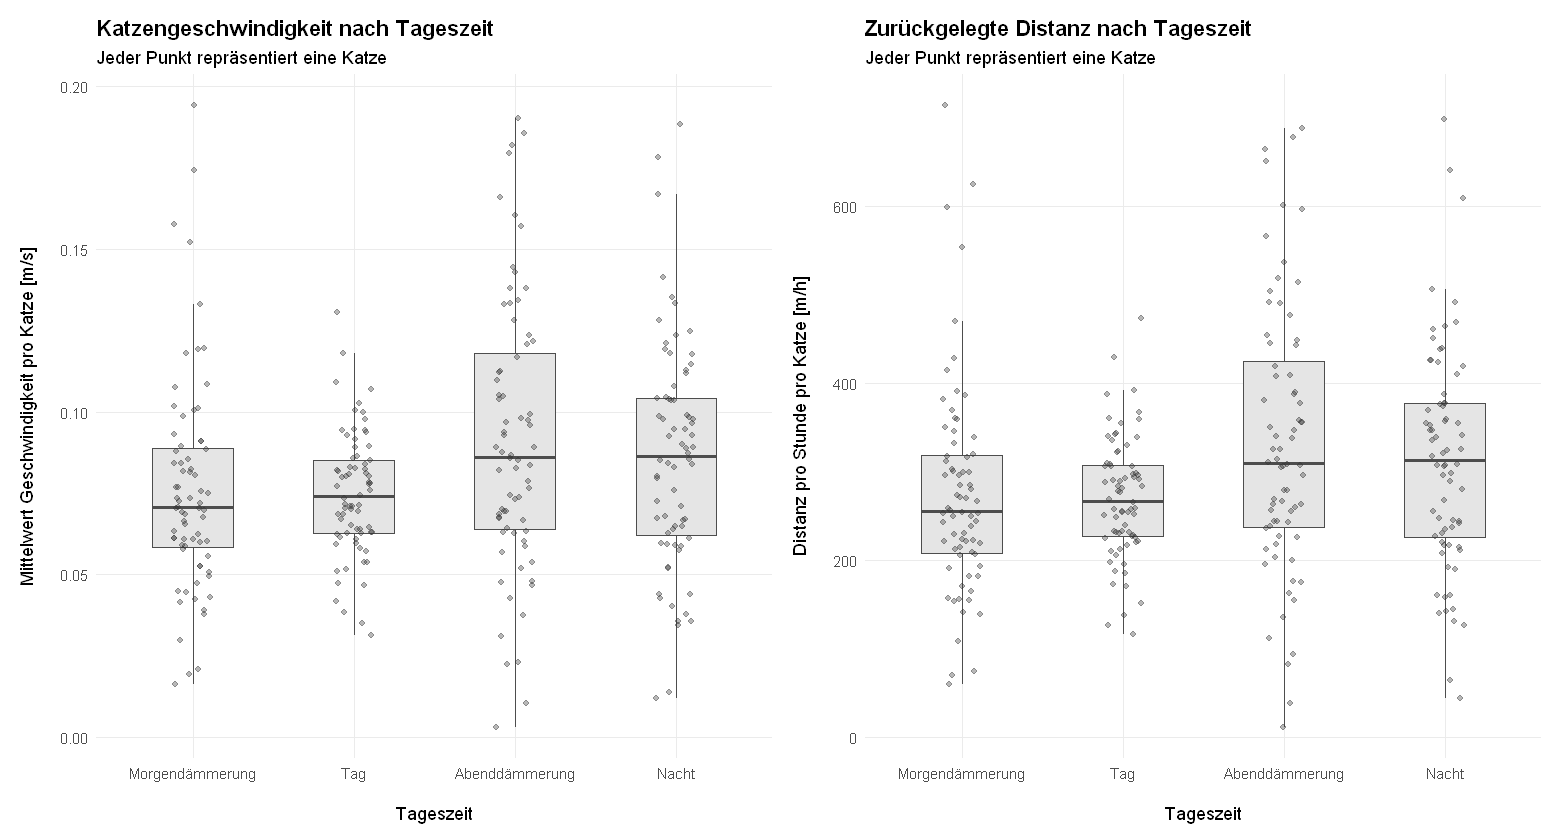

In [45]:
#| label: fig-plot1
#| fig-cap: "Tageszeitliche Aktivitätsmuster der Katzen (links: Mittelwert Geschwindigkeit in m/s; rechts: zurückgelegte Distanz in m/h pro Tageszeitkategorie)"

options(repr.plot.width = 13, repr.plot.height = 7)

boxplot_speed + boxplot_distance +
  plot_layout(ncol = 2)

## Home Ranges

Die Ergebnisse zeigen deutliche Unterschiede in der Grösse der Home Ranges (KDE 95%) zwischen den untersuchten Katzen (Min. 0.2 ha, Median 1.5 ha, Max. 377 ha). Die Sensitivitätsanalyse mit der 80 %-KDE führte erwartungsgemäss zu kleineren Flächenwerten, bestätigte jedoch die grundsätzlichen Muster der Analyse (siehe Abb. 2). 

In [37]:
###############################
# HR Plot beide
###############################

p95 <- ggplot() +
  geom_sf(data = hr_all, aes(fill = cat_id), alpha = 0.3, show.legend = FALSE) +
#  geom_sf(data = cats_all_joined, aes(color = cat_id), size = 0.2, show.legend = FALSE) +
  coord_sf(crs = st_crs(25833), datum = st_crs(25833)) +
  labs(
    title = "95% KDE Home Ranges"
  ) +
  theme_minimal()

p80 <- ggplot() +
  geom_sf(data = hr_all_80, aes(fill = cat_id), alpha = 0.3, show.legend = FALSE) +
#  geom_sf(data = cats_all_joined, aes(color = cat_id), size = 0.2, show.legend = FALSE) +
  coord_sf(crs = st_crs(25833), datum = st_crs(25833)) +
  labs(
    title = "80% KDE Home Range"
  ) +
  theme_minimal()

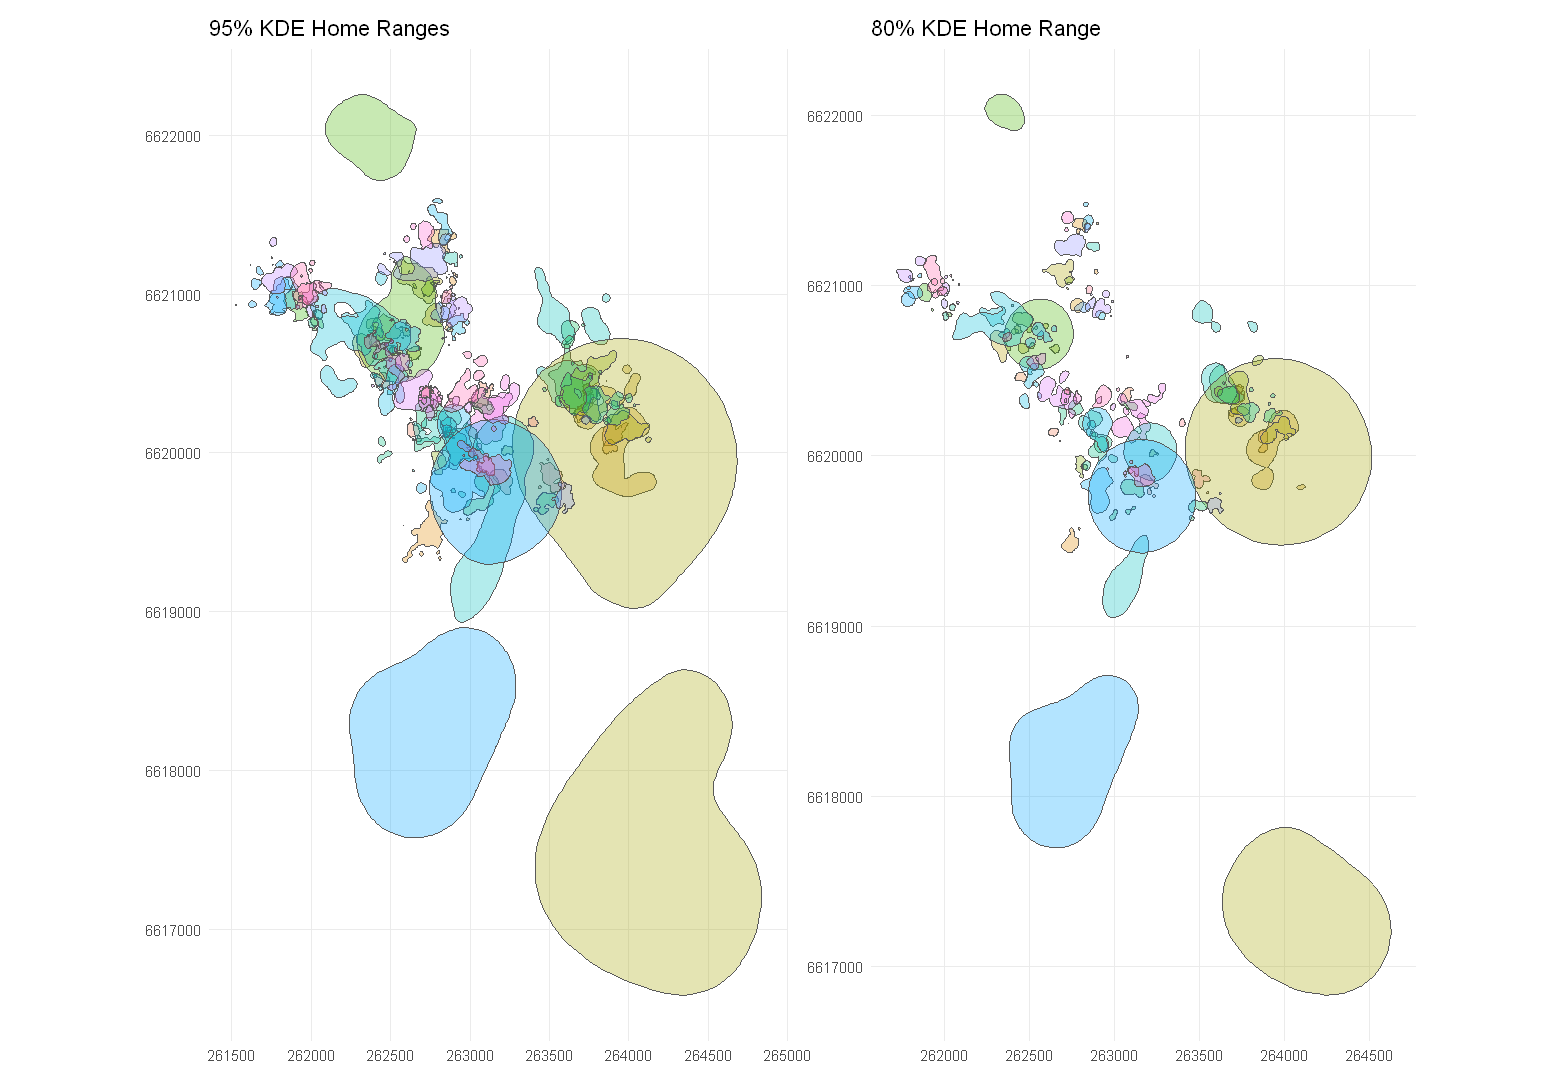

In [46]:
#| label: fig-plot2
#| fig-cap: "Kernel-Density-basierte Home-Range-Schätzung (95 % und 80% UD). Die Abbildung zeigt die räumliche Nutzung der 92 Katzen basierend auf der Kernel Density Estimation (KDE)"

options(repr.plot.width = 13, repr.plot.height = 9)

p95 + p80 +
  plot_layout(ncol = 2)

Die Verteilung der Flächengrössen war stark rechtsschief, was, wie in Abb. 3 sichtbar, auf wenige Individuen mit aussergewöhnlich grosse Home Ranges zurückzuführen ist. 

In [43]:
###############################
# Barplot mit HR-Grösse (95 KDE)
###############################

hr_barplot <- ggplot(hr_area_summary, aes(x = fct_reorder(cat_id, area_ha), y = area_ha)) +
  geom_col() +
  coord_flip() +
  labs(
    x = "Cat ID",
    y = "Home range area [ha]",
    title = "95% KDE home range size by cat",
    subtitle = "Home range area calculated from 95% kernel density estimates"
  ) +
  theme_minimal()
# hr_barplot

## Nur für die 20 grössten HR 
hr_area_top20 <- hr_area_summary %>%
  slice_max(area_ha, n = 20)

hr_barplot_top20 <- ggplot(hr_area_top20, aes(x = fct_reorder(cat_id, area_ha), y = area_ha)) +
  geom_col() +
  coord_flip() +
  labs(
    x = "Cat ID",
    y = "Home range area [ha]",
    title = "20 largest 95% KDE home ranges",
    subtitle = "Home range area calculated from 95% kernel density estimates"
  ) +
  theme_minimal()
# hr_barplot_top20

###############################
# Boxplot mit HR-Grösse
###############################

hr_boxplot <- ggplot(hr_area_summary, aes(x = "", y = area_ha)) +
  geom_boxplot(
    width = 0.3,
    outlier.shape = NA,
    fill = "grey90",
    color = "grey30"
  ) +
  geom_jitter(
    width = 0.08,
    alpha = 0.35,
    size = 1.4,
    color = "grey20"
  ) +
  scale_y_log10(
    limits = c(0.1, NA),
    breaks = c(0.1, 1, 10, 100),
    labels = c("0.1", "1", "10", "100")
  ) +
  labs(
    x = NULL,
    y = "95% KDE home range area [ha, log scale]",
    title = "Variation in home range size between cats",
    subtitle = "Each point represents one cat"
  ) +
  theme_minimal() +
  theme(
    panel.grid.minor = element_blank(),
    plot.title = element_text(face = "bold")
  )
# hr_boxplot

###############################
# HR-Grösse in Klassen einteilen
###############################

## Statistik anzeigen
# summary(hr_all$area_ha)

## in Klassen einteilen 

hr_area_summary_classified <- hr_area_summary %>%
  mutate(
    area_class = cut(
      area_ha,
      breaks = c(0, 1, 2, 4, 10, Inf),
      labels = c("0–1", "1–2", "2–4", "4–10", ">10"),
      include.lowest = TRUE,
      right = FALSE
    )
  )

## betrachten
# hr_area_summary_classified %>% count(area_class)

###############################
# Barplot mit HR-Grösse in Klassen
###############################

barplot_hr_class <- ggplot(hr_area_summary_classified, aes(x = area_class)) +
  geom_bar(
    fill = "grey90",
    color = "grey30",
    linewidth = 0.3
  ) +
  geom_text(
    stat = "count",
    aes(label = after_stat(count)),
    vjust = -0.8,
    size = 3
  ) +
  labs(
    x = "95% KDE Home Range Fläche [ha]",
    y = "Anzahl Katzen",
    title = "Verteilung der Home Range-Grössen",
    subtitle = "In Klassen gruppiert"
  ) +
  theme_minimal() +
  theme(
    panel.grid.minor = element_blank(),
    plot.title = element_text(face = "bold"),
    axis.title.x = element_text(margin = margin(t = 15)),
    axis.title.y = element_text(margin = margin(r = 15))
  )

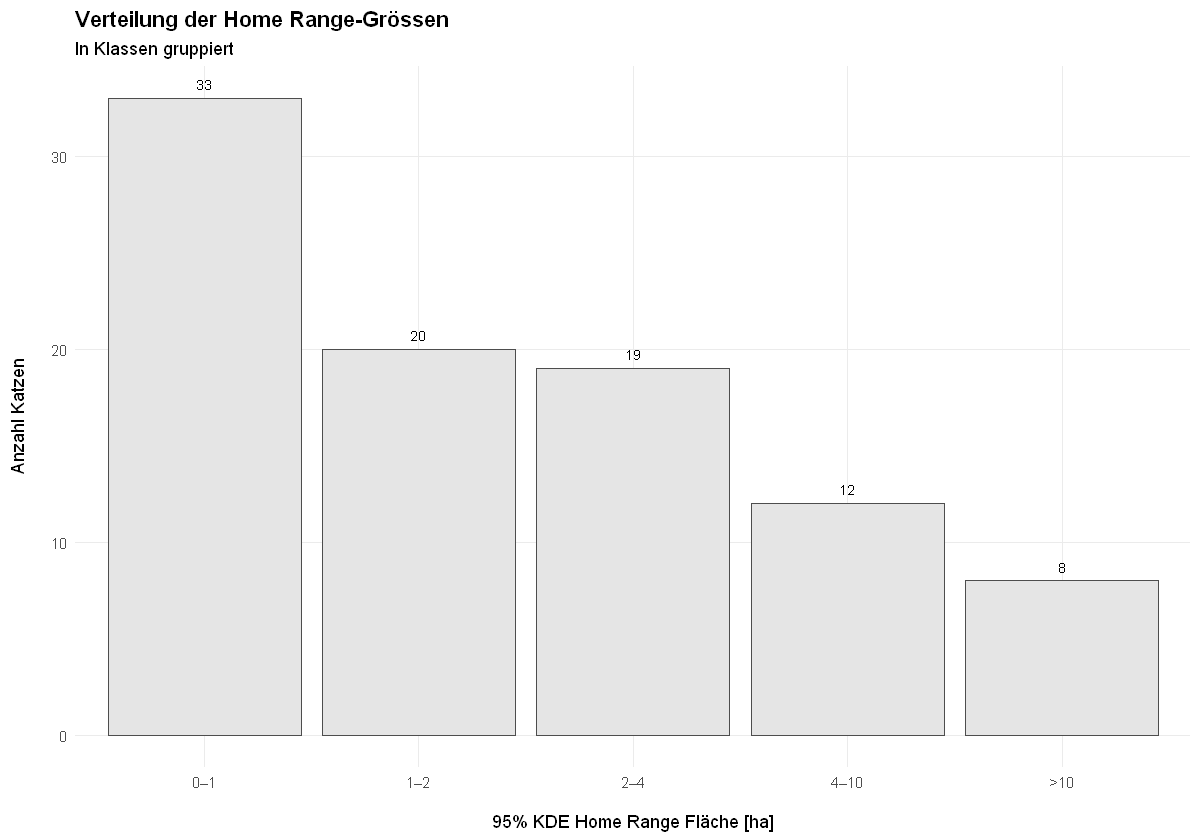

In [50]:
#| label: fig-plot3
#| fig-cap: "Häufigkeit der Katzen für verschiedene Kategorien der Grösse der Home Range in Hektaren"

options(repr.plot.width = 10, repr.plot.height = 7)
barplot_hr_class

Ein Vergleich zwischen urbanen (urban) und ländlichen (rural) Katzen zeigt eindrücklich auf, dass ländliche Katzen tendenziell grössere Home Ranges und eine grössere Variabilität davon aufweisen als urbane Katzen. Urbane Katzen nutzten hingegen kleinere und räumlich stärker konzentrierte Gebiete (siehe Abb. 4). 

In [54]:
###############################
# Boxplot der HR-Grösse nach Landytp
###############################

boxplot_hr_class <- ggplot(hr_area_environment, aes(x = cat_environment, y = area_ha)) +
  geom_boxplot(
    width = 0.5,
    outlier.shape = NA,
    fill = "grey90",
    color = "grey30"
  ) +
  geom_jitter(
    width = 0.12,
    alpha = 0.35,
    size = 1.4,
    color = "grey20"
  ) +
  scale_x_discrete(labels = c(
    "rural" = "Ländlich",
    "urban" = "Urban"
  )) +
  scale_y_log10(
    limits = c(0.1, NA),
    breaks = c(0.1, 1, 10, 100),
    labels = c("0.1", "1", "10", "100")
  ) +
  labs(
    x = "Dominanter Landtyp innerhalb der Home Range",
    y = "95% KDE Home Range-Grösse [ha, Log-Skala]",
    title = "Home Range-Grösse von urbanen und ländlichen Katzen",
    subtitle = "Klassifizierung der Katzen nach dominantem Landtyp innerhalb ihrer Home Range"
  ) +
  theme_minimal() +
  theme(
    panel.grid.minor = element_blank(),
    plot.title = element_text(face = "bold"),
    axis.title.x = element_text(margin = margin(t = 15)),
    axis.title.y = element_text(margin = margin(r = 15))
  )
# boxplot_hr_class

###############################
# Plot HR nach Landytp
###############################

# head(hr_area_environment)
# length(unique((hr_area_environment$cat_id)))

## Homeranges einfärben nach urban / ländlich
hr_all_environment <- hr_all %>%
  left_join(
    hr_area_environment %>%
      st_drop_geometry() %>%   # falls es ein sf-Objekt ist
      select(cat_id, cat_environment, urban_share, rural_share),
    by = "cat_id")

## Plotten
plot_hr_class <- ggplot(hr_all_environment) +
  geom_sf(
    aes(fill = cat_environment),
    alpha = 0.45,
    color = "grey30",
    linewidth = 0.3
  ) +
  coord_sf(crs = st_crs(hr_all), datum = st_crs(hr_all)) +
  scale_fill_manual(
    values = c(
      "urban" = "grey70",
      "rural" = "darkseagreen3"
    ),
    labels = c(
      "urban" = "Urban",
      "rural" = "Ländlich"
    )
  ) +
  labs(
    fill = "Dominanter Landtyp",
    title = "95% KDE Home Ranges klassifiziert als urban oder ländlich",
    subtitle = "Klassifizierung der Katzen nach dominantem Landtyp innerhalb ihrer Home Range"
  ) +
  theme_minimal() +
  theme(
    panel.grid.minor = element_blank(),
    plot.title = element_text(face = "bold"),    
    axis.title.x = element_text(margin = margin(t = 15)),
    axis.title.y = element_text(margin = margin(r = 15))
  )
# plot_hr_class

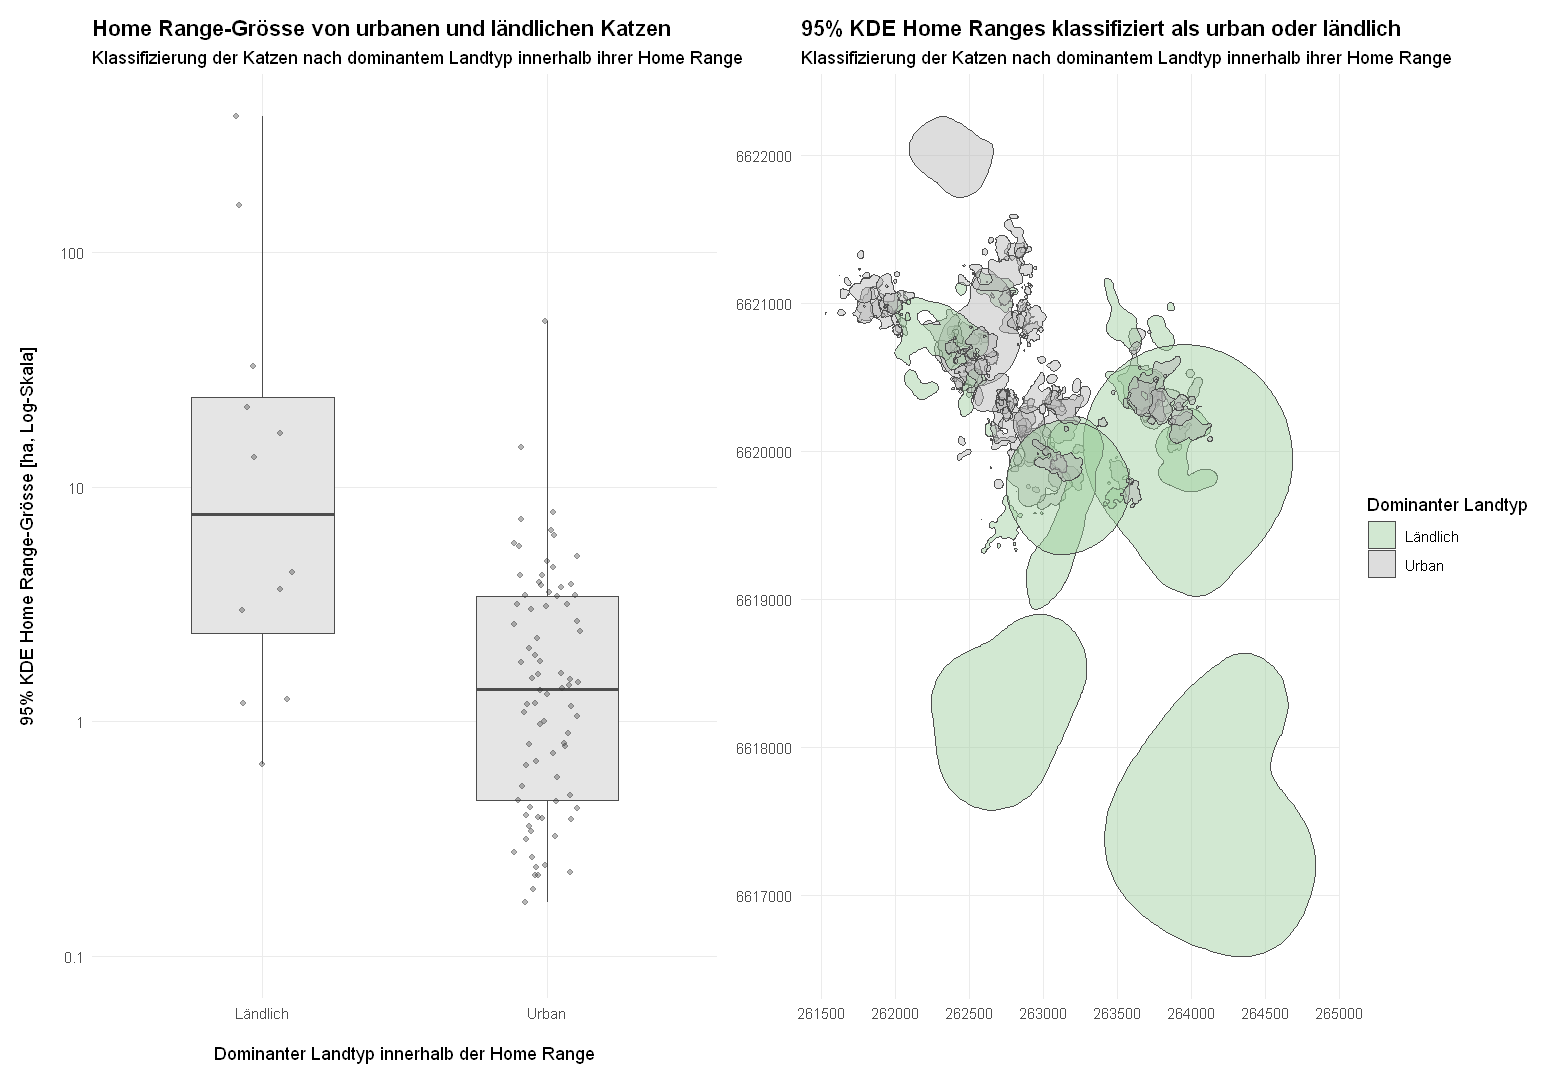

In [56]:
#| label: fig-plot4
#| fig-cap: "Vergleich der Home Range-Grössen zwischen urbanen und ländlichen Katzen. Links: Der Boxplot zeigt die Grösse der Home Range in Abhängigkeit des Katzentyps «rural» und «urban. Rechts: Die Abbildung visualisiert, was der Boxplot dargestellt hat. Grün sind Home Ranges von «ruralen» Katzen, grau von «urban» Katzen. (Abb. links: Skala ist logarithmisch)"

options(repr.plot.width = 13, repr.plot.height = 9)

boxplot_hr_class + plot_hr_class +
  plot_layout(ncol = 2)

## Begegnungen

Die Analyse identifiziert mehrere Begegnungen von Katzenpaaren. Die Häufigkeit der Begegnungen variiert stark zwischen den Individuen. Zeitlich zeigen sich klare Muster: Die meisten Begegnungen treten während der Nacht auf, insbesondere zwischen 00:00 und 01:00 Uhr oder in den Morgenstunden (08:00–11:00 Uhr) sowie am späten Abend (21:00–22:00 Uhr), während in den frühen Morgenstunden vergleichsweise wenige Begegnungen auftreten (siehe Abb. 5)

In [57]:
###############################
# Zusammenfassung pro Katzenpaar
###############################

meet_summary_pairs <- cat_meets %>%
  group_by(cat_id, cat_id_right) %>%
  summarise(
    n_meet_fixes = n(),
    .groups = "drop"
  ) %>%
  arrange(desc(n_meet_fixes))
# meet_summary_pairs

## wie viele "Katzenpaare" gibt es, die sich getroffen haben?
# nrow(meet_summary_pairs)

###############################
# Wer trifft wen? Balkenplot pro Katzenpaar
###############################

meet_summary_pairs <- cat_meets %>%
  mutate(
    pair_id = paste(cat_id, cat_id_right, sep = " - ")
  ) %>%
  group_by(pair_id) %>%
  summarise(
    n_meet_fixes = n(),
    .groups = "drop"
  ) %>%
  arrange(desc(n_meet_fixes))
# head(meet_summary_pairs)

barplot_pairs <- meet_summary_pairs %>%
  slice_max(n_meet_fixes, n = 20) %>%
  ggplot(aes(x = fct_reorder(pair_id, n_meet_fixes), y = n_meet_fixes)) +
  geom_col() +
  coord_flip() +
  labs(
    x = "Cat pair",
    y = "Number of meet-fixes",
    title = "Most frequent cat meetings",
    subtitle = "Meet-fix: distance ≤ 10 m and time difference ≤ 60 s"
  ) +
  theme_minimal()
# barplot_pairs

###############################
# Wo finden Meets statt? Räumlicher Plot
###############################

## Dataet vorbereiten
meet_points <- cat_meets %>%
  mutate(
    X_meet = (X + X_right) / 2,
    Y_meet = (Y + Y_right) / 2,
    pair_id = paste(cat_id, cat_id_right, sep = " - ")
  ) %>%
  st_as_sf(coords = c("X_meet", "Y_meet"), crs = 25833, remove = FALSE)

## Plotten
plot_meet_loc <- ggplot() +
  geom_sf(data = cats_all_joined, aes(color = cat_id), size = 0.1, alpha = 0.15, show.legend = FALSE) +
  geom_sf(data = meet_points, color = "black", size = 1.2, alpha = 0.7) +
  coord_sf(crs = st_crs(25833), datum = st_crs(25833)) +
  labs(
    title = "Spatial distribution of cat meet-fixes",
    subtitle = "Black points show locations where two cats were within 10 m and 60 s"
  ) +
  theme_minimal()
# plot_meet_loc

###############################
# Wann finden Meets statt? Zeitlicher Plot
###############################

## Hilfsvariable hour fürs plotten
cat_meets_time <- cat_meets %>%
  mutate(
    hour = hour(datetime)
  )

## Plotten
plot_meet_hour <- ggplot(cat_meets_time, aes(x = hour)) +
  geom_histogram(
    binwidth = 1,
    fill = "grey90",
    color = "grey30",
    linewidth = 0.3
  ) +
  scale_x_continuous(
    breaks = 0:23
  ) +
  labs(
    x = "Stunde des Tages",
    y = "Anzahl Begegnungen",
    title = "Katzenbegegnungen nach Uhrzeit",
    subtitle = "Begegnung: Distanz ≤ 10 m und Zeitdifferenz ≤ 60 sek"
  ) +
  theme_minimal() +
  theme(
    panel.grid.minor = element_blank(),
    plot.title = element_text(face = "bold"),
    axis.title.x = element_text(margin = margin(t = 15)),
    axis.title.y = element_text(margin = margin(r = 15))
  )

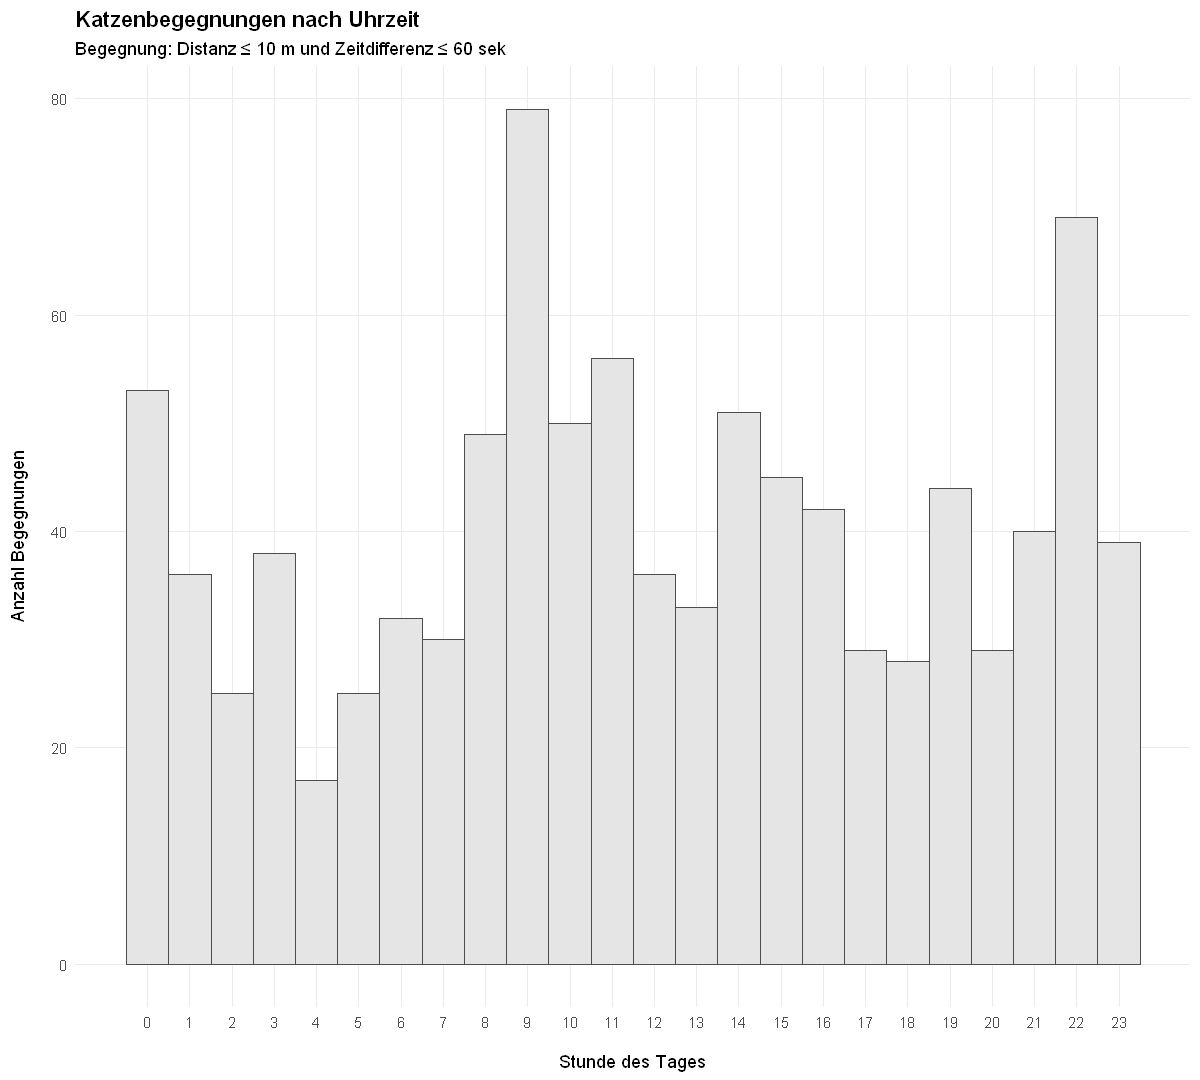

In [59]:
#| label: fig-plot5
#| fig-cap: "Darstellung der Häufigkeit von „Begegnungen“ von Katzen (<= 10m, <=60s) über den Tagesverlauf"

options(repr.plot.width = 10, repr.plot.height = 9)

plot_meet_hour

Die räumliche Analyse zeigt zudem, dass die Anzahl der Begegnungen mit zunehmender Überlappung zunächst ansteigt, jedoch bei mittlerer Überlappung von 3 Home Ranges ein Maximum erreicht und ab 4 Überlappungen wieder abnimmt. (Siehe Abb. 6, rechts) Insgesamt deuten die Ergebnisse darauf hin, dass räumliche Nähe und gemeinsame Raumnutzung die Wahrscheinlichkeit von Begegnungen erhöhen, die Verteilung der Begegnungen jedoch stark heterogen über die Katzenpaare ist (siehe Abb. 6, links).

In [63]:
###############################
# Meets räumlich mit HR
###############################

## Dataset vorbereiten (Meet auf halber Strecke)
meet_points <- cat_meets %>%
  mutate(
    X_meet = (X + X_right) / 2,
    Y_meet = (Y + Y_right) / 2
  ) %>%
  st_as_sf(coords = c("X_meet", "Y_meet"), crs = 25833, remove = FALSE)

## Plotten mit HR im gleichen Stil
plot_meet_hr <- ggplot() +
  geom_sf(
    data = hr_all_environment,
    aes(fill = cat_environment),
    alpha = 0.45,
    color = "grey30",
    linewidth = 0.3
  ) +
  geom_sf(
    data = meet_points,
    size = 0.8,
    alpha = 0.8,
    color = "grey20"
  ) +
  coord_sf(crs = st_crs(25833), datum = st_crs(25833)) +
  scale_fill_manual(
    values = c(
      "urban" = "grey70",
      "rural" = "darkseagreen3"
    ),
    labels = c(
      "urban" = "Urban",
      "rural" = "Ländlich"
    )
  ) +
  labs(
    fill = "Dominanter Landtyp",
    title = "Räumliche Verteilung der Begegnungen",
    subtitle = "Begegnungspunkte dargestellt mit 95% KDE Home Ranges"
  ) +
  theme_minimal() +
  theme(
    panel.grid.minor = element_blank(),
    plot.title = element_text(face = "bold"),
    axis.title.x = element_text(margin = margin(t = 15)),
    axis.title.y = element_text(margin = margin(r = 15))
  )
# plot_meet_hr

###############################
# Meets durch überlappende HR erklären
###############################

## Hier wird zusätzich untersucht, inwiefern die Dichte der Meets in Zusammenhang 
## steht mit der Anzahl Überlappungen der Home Ranges (95% KDE).
## Frage: Treten Meets häufiger in Bereichen auf, wo sich viele Home Ranges überlappen?

# head(hr_all_environment)

## Meet-Punkte als Mittelpunkt zwischen beiden Katzenpositionen berechnen
## X/Y und X_right/Y_right stammen aus cats_all_joined und sind daher in EPSG:25833
meet_points <- cat_meets %>%
  mutate(
    X_meet = (X + X_right) / 2,
    Y_meet = (Y + Y_right) / 2,
    pair_id = paste(cat_id, cat_id_right, sep = " - ")
  ) %>%
  st_as_sf(
    coords = c("X_meet", "Y_meet"),
    crs = st_crs(cats_all_joined),
    remove = FALSE
  )

## Sicherstellen, dass hr_all im gleichen CRS ist wie meet_points
hr_all <- st_transform(hr_all, st_crs(meet_points))

## Anzahl überlappender Home Ranges am jeweiligen Meet-Punkt berechnen
meet_points$overlap_n <- lengths(st_intersects(meet_points, hr_all))

## Ergebnis prüfen
table_meets <- meet_points %>%
  st_drop_geometry() %>%
  count(overlap_n) %>%
  arrange(overlap_n)
# table_meets

## Plotten
barplot_meet_hr <- ggplot(meet_points %>% st_drop_geometry(), aes(x = overlap_n)) +
  geom_bar(
    fill = "grey90",
    color = "grey30",
    linewidth = 0.3
  ) +
  geom_text(
    stat = "count",
    aes(label = after_stat(count)),
    vjust = -0.8,
    size = 3
  ) +
  scale_x_continuous(
    breaks = 0:8) +
  labs(
    x = "Anzahl überlappende 95% KDE Home Ranges",
    y = "Anzahl Begegnungen",
    title = "Begegnungen nach Anzahl überlappender Home Ranges",
    subtitle = "Begegnung: Distanz ≤ 10 m und Zeitdifferenz ≤ 60 sek"
  ) +
  theme_minimal() +
  theme(
    panel.grid.minor = element_blank(),
    plot.title = element_text(face = "bold"),
    axis.title.x = element_text(margin = margin(t = 15)),
    axis.title.y = element_text(margin = margin(r = 15))
      )
# barplot_meet_hr

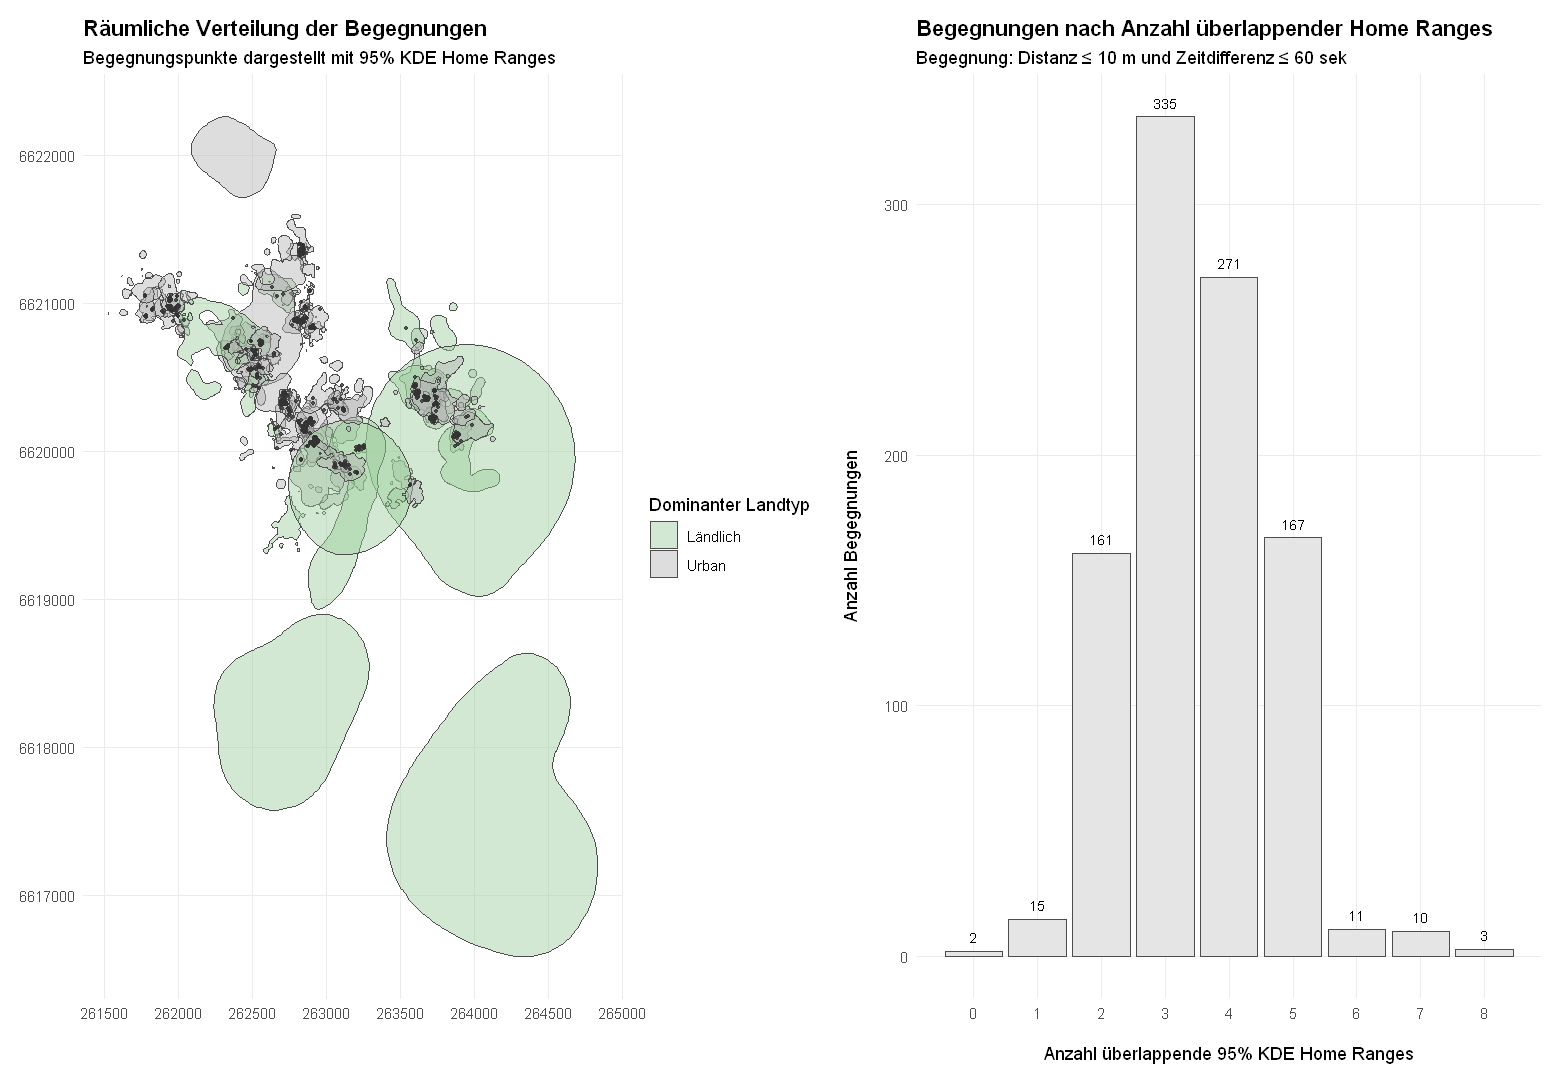

In [64]:
#| label: fig-plot6
#| fig-cap: "Links: Der Zusammenhang zwischen Home Range-Überlappung und «Begegnungen». Rechts: Die Abbildung zeigt die Anzahl von Begegnungen in Abhängigkeit der räumlichen Überlappung."

options(repr.plot.width = 13, repr.plot.height = 9)

plot_meet_hr + barplot_meet_hr +
  plot_layout(ncol = 2)

# Diskussion 

Die Aktivitätsmuster zeigen, dass die untersuchten Katzen insbesondere während der Abenddämmerung und der Nacht aktiv sind. Dieses Muster entspricht dem häufig beschriebenen dämmerungs- und nachtaktiven Verhalten von Katzen (Merčnik et al., 2023). Die verwendeten Bewegungsparameter Geschwindigkeit und zurückgelegte Distanz stellen zentrale Grössen der Computational Movement Analysis dar und ermöglichen eine quantitative Analyse des Bewegungsverhaltens der Katzen aus Ás (Dodge et al., 2008). 

Gleichzeitig  bringen die Resultate die von Laube (2014) beschriebene Problematik des „Semantic Gap“ hervor. Obwohl erhöhte Geschwindigkeiten und grössere Distanzen auf höhere Aktivität hindeuten, kann aus den Bewegungsdaten nicht eindeutig auf das tatsächliche Verhalten geschlossen werden. Eine erhöhte Geschwindigkeit kann beispielsweise Jagdverhalten oder Ortswechsel widerspiegeln. Dies bestätigt auch Shamoun-Baranes et al. (2012). 

Der verwendete Schwellenwert von 5 Minuten für zulässige Zeitabstände stellt einen methodischen Kompromiss zwischen Datenqualität und Datenverlust dar. Zwar mindert er das Problem des «Granularity Griefs», das Problem bleibt aber bestehen und «verpasst» oder unterschätzt kurzfristige Bewegungen (Laube und Purves, 2011).  Bei grossen Zeitabständen zwischen Messungen ist unklar, ob die Katze konstant gleich schnell unterwegs war oder zwischen schnellen und langsamen Bewegungen wechselte. Dies wurde auch im Kurs besprochen. 

Die Analyse der Home Ranges zeigt deutliche Unterschiede zwischen urbanen und ländlichen Katzen. Die Einteilung urban/rural ist in diesem Datensatz nur eingeschränkt interpretierbar, da es sich insgesamt um ein ländlich geprägtes Gebiet handelt. Trotzdem liefert sie wichtige Hinweise für weitere Forschung, hier genauer hinzuschauen.

Die Untersuchung raumzeitlicher Begegnungen stellt einen weiteren Schritt von der reinen Bewegungsanalyse zur Interpretation möglicher sozialer Interaktionen dar. Die Aussagekraft von Bewegungsdaten entsteht erst durch die Einbettung in ihren räumlichen Kontext.  Dennoch erlaubt die gewählte Meet-Definition keine Aussage über tatsächliche soziale Interaktionen. Die Analyse identifiziert lediglich räumliche und zeitliche Nähe zwischen Individuen. Intuitiv wurde entweder mit mehr Begegnungen bei stärkerer räumlicher Überlappung oder umgekehrt eine stärkere territoriale Vermeidung gerechnet. Die Resultate deutet darauf hin, dass die Beziehung zwischen räumlicher Nähe und Begegnungshäufigkeit nicht linear ist und weitere Forschung nötig ist. Ob dabei direkte Kontakte, soziale Beziehungen oder zufällige Begegnungen vorlagen, kann anhand der GPS-Daten nicht beurteilt werden (Dodge et al., 2013).

Die Ergebnisse verdeutlichen insgesamt die Möglichkeiten, aber auch die Grenzen moderner Bewegungsdatenanalysen. Die Kombination aus Aktivitätsanalysen, Home- Range und Begegnungen-Analysen erlaubt eine differenzierte Betrachtung der Bewegungsmuster von Katzen, erfordert jedoch weiterführende Forschung und vor allem GPS- Punkte ohne spatial offset und kürzeren Zeitabständen zur Interpretation der beobachteten Muster (Laube, 2014). 

# Limitationen

Die vorliegende Analyse unterliegt mehreren methodischen Einschränkungen. Erstens wurde Aktivität ausschliesslich über Geschwindigkeit und zurückgelegte Distanz operationalisiert. Weitere Verhaltensindikatoren wie Beschleunigung, Aufenthaltsdauer oder explizite Verhaltensklassifikationen wurden nicht berücksichtigt. Dadurch bleibt Aktivität ein indirektes Mass für das tatsächliche Verhalten der Tiere (Shamoun-Baranes et al., 2012).
Zweitens beeinflusst die zeitliche Auflösung der GPS-Daten die berechneten Bewegungsparameter. Trotz Ausschluss aller Positionspaare mit Zeitdifferenzen über fünf Minuten bleibt das von Laube und Purves (2011) beschriebene Problem des „Granularity Grief“ bestehen.
Drittens können Messungenauigkeiten bei raumzeitlichen Begegnungen dazu führen, dass Begegnungen über- oder unterschätzt werden. Die Schwellenwerte von 10 Metern und 60 Sekunden stellen dabei einen pragmatischen Kompromiss zwischen biologischer Plausibilität und Datenqualität dar (Long et al., 2014). 
Schliesslich schränkt der aus Datenschutzgründen angewendete spatial offset die exakte räumliche Lokalisierung ein. Punktgenaue Analysen sind dadurch limitiert, während aggregierte Auswertungen, etwa zur Landschaftsklassifikation (urban/rural), weiterhin möglich bleiben.


# Literaturverzeichnis

